# Study Case 2 — Data Cleaning, Transformasi & Dashboard
### Platform Konseling B2B — Riliv

**Tujuan notebook ini:**
1. Mengeksplorasi raw data pendaftaran konseling yang berformat *wide* (pasangan kolom `Question N` / `Response N`).
2. Membangun kamus **mapping** dari seluruh variasi label pertanyaan ke nama kolom standar.
3. Mentransformasikan data ke bentuk **tidy** (satu baris = satu pendaftaran, satu kolom = satu jenis informasi).
4. Melakukan pembersihan data tambahan (usia, gender, kapitalisasi, dsb).
5. Menghasilkan insight awal (EDA) sebagai bahan dashboard.

Seluruh logika mapping & transformasi disimpan sebagai modul terpisah (`mapping.py`, `transform.py`) supaya bisa dipakai ulang oleh dashboard Streamlit (`dashboard_app.py`), sehingga logika transformasi konsisten di satu tempat (single source of truth).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
plt.rcParams['figure.dpi'] = 110

from mapping import QUESTION_MAPPING, normalize_label, FINAL_COLUMN_ORDER
from transform import (load_raw, melt_to_long, pivot_to_tidy, apply_cleaning,
                        clean_usia, clean_gender, standardize_perusahaan,
                        clean_status_kepegawaian)

print("Libraries & modul mapping/transform berhasil dimuat.")

Libraries & modul mapping/transform berhasil dimuat.


## 1. Load Raw Data

Dataset asli: `data/Raw_Data.xlsx` (sheet `raw`) — 7.270 baris pendaftaran konseling, 24 kolom
(4 kolom metadata + 10 pasang kolom `Question N` / `Response N`).

In [2]:
raw = load_raw()
print("Shape:", raw.shape)
raw.head(3)

Shape: (7270, 24)


,Invitee Name,Start Date & Time,End Date & Time,Event Created Date & Time,Question 1,Response 1,Question 2,Response 2,Question 3,Response 3,Question 4,Response 4,Question 5,Response 5,Question 6,Response 6,Question 7,Response 7,Question 8,Response 8,Question 9,Response 9,Question 10,Response 10
0,Responden_0001,2024-01-05 14:00:00,2024-01-05 15:00:00,2023-12-22 16:44:00,Kode Perusahaan,PERUSAHAAN_001,Divisi,Activation,Usia,25,Gender,Laki-laki,Pilihan layanan konseling,Konseling Call,Topik permasalahan yang ingin dibahas pada ses...,Sosial,Gambaran singkat permasalahan,sebenarnya lagi tidak ada permasalahan yang be...,Dari mana Anda mengetahui informasi pendaftara...,Informasi dari perusahaan,"Dalam program konseling bersama Riliv, ringkas...",Saya bersedia,NaN,NaN
1,Responden_0002,2024-01-02 19:30:00,2024-01-02 20:30:00,2023-12-24 12:18:00,Kode Perusahaan,PERUSAHAAN_001,Divisi,Customer Support,Usia,23,Gender,Perempuan,Pilihan layanan konseling,Konseling Call,Topik permasalahan yang ingin dibahas pada ses...,Kecemasan,Gambaran singkat permasalahan,overthinking,Dari mana Anda mengetahui informasi pendaftara...,Informasi dari perusahaan,"Dalam program konseling bersama Riliv, ringkas...",Saya bersedia,NaN,NaN
2,Responden_0003,2024-01-03 18:30:00,2024-01-03 19:30:00,2023-12-25 06:19:00,Kode Perusahaan,PERUSAHAAN_002,Divisi,Departemen Operasi Pabrik 3,Usia,32,Gender,Laki-laki,Pilihan layanan konseling,Konseling Video Call,Topik permasalahan yang ingin dibahas pada ses...,Kendali emosi,Gambaran singkat permasalahan,Ada saatnya tiba-tiba gampang banget marah. Ga...,Dari mana Anda mengetahui informasi pendaftara...,Informasi dari perusahaan,"Dalam program konseling bersama Riliv, ringkas...",Saya tidak bersedia,NaN,NaN


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7270 entries, 0 to 7269
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Invitee Name               7270 non-null   str           
 1   Start Date & Time          7270 non-null   datetime64[us]
 2   End Date & Time            7270 non-null   datetime64[us]
 3   Event Created Date & Time  7270 non-null   datetime64[us]
 4   Question 1                 7215 non-null   str           
 5   Response 1                 6946 non-null   object        
 6   Question 2                 6834 non-null   str           
 7   Response 2                 6549 non-null   object        
 8   Question 3                 5702 non-null   str           
 9   Response 3                 5576 non-null   object        
 10  Question 4                 5273 non-null   str           
 11  Response 4                 5255 non-null   object        
 12  Question 5       

## 2. Eksplorasi Data — Variasi Label Pertanyaan

Karena form pendaftaran sudah beberapa kali direvisi, isi kolom `Question 1..10` tidak konsisten:
label yang maknanya sama bisa ditulis berbeda-beda (contoh: `"Kode Perusahaan"` vs `"Kode perusahaan"`
vs `"Company Code"`). Langkah pertama adalah mendata **seluruh label unik** yang muncul, beserta
frekuensi kemunculannya, supaya proses mapping bisa dilakukan secara lengkap & terukur.

In [4]:
q_cols = [f"Question {i}" for i in range(1, 11)]
all_questions = pd.concat([raw[c] for c in q_cols]).dropna().astype(str)
all_questions_norm = all_questions.apply(normalize_label)

unique_labels = all_questions_norm.value_counts()
print(f"Jumlah label pertanyaan UNIK yang ditemukan: {len(unique_labels)}")
print(f"Total kemunculan (semua slot Question 1-10, tidak kosong): {len(all_questions_norm)}")
unique_labels.head(20)

Jumlah label pertanyaan UNIK yang ditemukan: 118
Total kemunculan (semua slot Question 1-10, tidak kosong): 46964


Gender                                                                                                                                                                                                                                        4692
Usia                                                                                                                                                                                                                                          4476
Gambaran singkat permasalahan                                                                                                                                                                                                                 3969
Dari mana Anda mengetahui informasi pendaftaran program kesehatan mental?                                                                                                                                                                     3551
Pilihan layanan konseling   

In [5]:
# Contoh nyata masalah inkonsistensi label: variasi penulisan "kode perusahaan"
sample_variants = [l for l in unique_labels.index if "perusahaan" in l.lower() or "company" in l.lower()]
for v in sample_variants:
    print(f"{unique_labels[v]:>5}  {v!r}")

 2354  'Dalam program konseling bersama Riliv, ringkasan permasalahan yang Anda ceritakan kepada Psikolog Riliv selama sesi konseling akan disampaikan ke perusahaan dengan tetap menjaga kerahasiaan nama Anda. Apakah Anda bersedia?'
 1691  'Kode Perusahaan'
 1369  'Kode perusahaan'
  537  'Nama Perusahaan'
  495  'Nama perusahaan'
  223  'Company Code'
  195  "During the Riliv counselling program, the brief summary of your problems discussed with the Riliv's Psychologist will be submitted to the company anonymously. Do you agree to submit the brief summary of your session?"
  125  'Sebelum melanjutkan proses pendaftaran, harap baca dan pahami Informed Consent (IC) yang telah kami sediakan melalui tautan berikut: https://bit.ly/InformedConsent-Konseling-RilivforCompany Silakan pilih salah satu opsi berikut:'
  110  'Perusahaan'
  106  'Dalam program konseling bersama Riliv, ringkasan permasalahan yang Anda ceritakan kepada CFP Riliv selama sesi konseling akan disampaikan ke perusahaan de

### Temuan Kualitas Data Lain

* **Baris "sesi lanjutan"**: ada baris yang hanya berisi *Counseling Code* tanpa detail lain
  (kemungkinan sesi lanjutan yang datanya sudah terekam di sesi sebelumnya).
* **Baris booking kosong**: sebagian baris ternyata tidak punya isian `Question` sama sekali
  (form tidak terisi, tapi jadwal booking tetap tercatat).
* **Label yang tampak seperti kesalahan input**: contoh `"Konseling Psikologi Video Call - 60'"` muncul
  sebagai isi kolom *Question* (bukan sebagai *Response*), dengan isi *Response* berupa data uji
  seperti `"60"`, `"ywyys"`, `"Testing"` — ini kemungkinan glitch input pada form dan tetap
  dipetakan ke kolom `Other_Info` supaya tetap tertelusuri, bukan dibuang begitu saja.

In [6]:
only_code_mask = raw.apply(
    lambda r: pd.notna(r["Question 1"]) and "code" in str(r["Question 1"]).lower()
    and all(pd.isna(r[f"Question {i}"]) for i in range(2, 11)),
    axis=1,
)
empty_form_mask = raw[q_cols].isna().all(axis=1)

print(f"Baris yang HANYA berisi Counseling/Consultation Code: {only_code_mask.sum()}")
print(f"Baris booking tanpa isian Question sama sekali        : {empty_form_mask.sum()}")
raw.loc[only_code_mask, ["Invitee Name", "Question 1", "Response 1"]].head(3)

Baris yang HANYA berisi Counseling/Consultation Code: 361
Baris booking tanpa isian Question sama sekali        : 55


,Invitee Name,Question 1,Response 1
512,Responden_0363,Counseling Code,05b30eb3-5475-4266-a2b9-ff475b277142
513,Responden_0363,Counseling Code,64f17c01-f2fb-432f-89db-a634139bc73d
514,Responden_0363,Counseling Code,1cffa31c-a86b-4bf0-8e62-ec172fd8d6cb


## 3. Kamus Mapping (Question Label → Kolom Standar)

Seluruh 121 label unik dikelompokkan secara manual ke dalam **24 kategori informasi** berdasarkan makna
pertanyaannya (lihat modul `mapping.py` untuk daftar lengkapnya). Beberapa contoh kelompok:

| Kategori (kolom hasil) | Jumlah variasi label yang digabung |
|---|---|
| Perusahaan | 10 variasi |
| Divisi_Departemen | 9 variasi |
| Jenis_Layanan_Konseling | 10 variasi |
| Persetujuan_Data_Consent | 12 variasi |
| Status_Kepegawaian | 7 variasi |

Fungsi `normalize_label()` merapikan whitespace/format sebelum pencocokan, supaya label yang hanya
berbeda newline/spasi tetap dianggap sama.

In [7]:
from collections import Counter
cat_counts = Counter(QUESTION_MAPPING.values())
mapping_summary = (
    pd.Series(cat_counts)
    .sort_values(ascending=False)
    .rename("Jumlah Variasi Label Digabung")
    .to_frame()
)
mapping_summary

,Jumlah Variasi Label Digabung
Nama_Karyawan_Terkait_Keluarga,12
Persetujuan_Data_Consent,11
Perusahaan,10
Jenis_Layanan_Konseling,10
Topik_Permasalahan,9
Divisi_Departemen,9
Data_Kesehatan_Fisik,8
Status_Kepegawaian,7
Nomor_WhatsApp,6
Gambaran_Singkat_Masalah,6


In [8]:
# Verifikasi: pastikan SEMUA label unik di data sudah termapping (tidak ada yang terlewat)
unmapped = [l for l in unique_labels.index if l not in QUESTION_MAPPING]
print(f"Label yang belum termapping: {len(unmapped)}")
assert len(unmapped) == 0, "Masih ada label yang belum dipetakan!"
print("✅ Seluruh label pertanyaan sudah terpetakan ke kategori standar.")

Label yang belum termapping: 0
✅ Seluruh label pertanyaan sudah terpetakan ke kategori standar.


## 4. Transformasi Wide → Long → Tidy

Proses dilakukan dalam 2 tahap:

1. **`melt_to_long()`** — ubah 10 pasang kolom Question/Response menjadi format panjang (long):
   satu baris = satu pasangan question-response yang terisi, plus kolom `Category` hasil mapping.
2. **`pivot_to_tidy()`** — pivot balik dari long ke wide, tapi kali ini kolomnya adalah **kategori
   standar**, bukan lagi `Question N`/`Response N`. Basis barisnya adalah seluruh baris raw data asli
   (bukan hanya baris yang long_df-nya terisi), supaya baris booking yang form-nya kosong tetap muncul
   sebagai satu baris pendaftaran.

In [9]:
long_df = melt_to_long(raw)
print("Bentuk data long:", long_df.shape)
long_df[["row_id", "Invitee Name", "slot", "Question", "Response", "Question_norm", "Category"]].head(8)

Bentuk data long: (46964, 10)


,row_id,Invitee Name,slot,Question,Response,Question_norm,Category
0,0,Responden_0001,1,Kode Perusahaan,PERUSAHAAN_001,Kode Perusahaan,Perusahaan
1,1,Responden_0002,1,Kode Perusahaan,PERUSAHAAN_001,Kode Perusahaan,Perusahaan
2,2,Responden_0003,1,Kode Perusahaan,PERUSAHAAN_002,Kode Perusahaan,Perusahaan
3,3,Responden_0003,1,Kode Perusahaan,PERUSAHAAN_002,Kode Perusahaan,Perusahaan
4,4,Responden_0004,1,Kode perusahaan,PERUSAHAAN_003,Kode perusahaan,Perusahaan
5,5,Responden_0005,1,Kode perusahaan,PERUSAHAAN_003,Kode perusahaan,Perusahaan
6,6,Responden_0006,1,Kode Perusahaan,PERUSAHAAN_001,Kode Perusahaan,Perusahaan
7,7,Responden_0007,1,Kode perusahaan,PERUSAHAAN_004,Kode perusahaan,Perusahaan


In [10]:
tidy_raw = pivot_to_tidy(long_df, raw)
print("Bentuk data tidy (sebelum cleaning tambahan):", tidy_raw.shape)
tidy_raw.head(3)

Bentuk data tidy (sebelum cleaning tambahan): (7270, 28)


,Invitee Name,Start Date & Time,End Date & Time,Event Created Date & Time,Alergi_Riwayat_Penyakit,Bahasa_Konsultasi,Data_Kesehatan_Fisik,Divisi_Departemen,Factory_Area,Gambaran_Singkat_Masalah,Gender,Jenis_Layanan_Konseling,Jenis_Olahraga,Kode_Sesi_Konseling,Konseling_Kecanduan_Rokok,NIK,Nama_Karyawan_Terkait_Keluarga,Nomor_WhatsApp,Other_Info,Persetujuan_Data_Consent,Perusahaan,Posisi_Jabatan,Share_ID,Status_Kepegawaian,Sumber_Informasi,Tipe_Program_Nutrisi,Topik_Permasalahan,Usia
0,Responden_0001,2024-01-05 14:00:00,2024-01-05 15:00:00,2023-12-22 16:44:00,NaN,NaN,NaN,Activation,NaN,sebenarnya lagi tidak ada permasalahan yang be...,Laki-laki,Konseling Call,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Saya bersedia,PERUSAHAAN_001,NaN,NaN,NaN,Informasi dari perusahaan,NaN,Sosial,25
1,Responden_0002,2024-01-02 19:30:00,2024-01-02 20:30:00,2023-12-24 12:18:00,NaN,NaN,NaN,Customer Support,NaN,overthinking,Perempuan,Konseling Call,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Saya bersedia,PERUSAHAAN_001,NaN,NaN,NaN,Informasi dari perusahaan,NaN,Kecemasan,23
2,Responden_0003,2024-01-03 18:30:00,2024-01-03 19:30:00,2023-12-25 06:19:00,NaN,NaN,NaN,Departemen Operasi Pabrik 3,NaN,Ada saatnya tiba-tiba gampang banget marah. Ga...,Laki-laki,Konseling Video Call,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Saya tidak bersedia,PERUSAHAAN_002,NaN,NaN,NaN,Informasi dari perusahaan,NaN,Kendali emosi,32


## 5. Pembersihan Data Tambahan

Setelah pivot, masih ada beberapa isu format yang perlu dirapikan:

* **Usia** — campuran angka murni (`25`) dan teks (`"25 tahun"`) → diekstrak jadi angka. Ditemukan juga
  beberapa nilai di luar rentang wajar (tahun lahir `1989`, angka mirip nomor telepon) → diubah ke `NaN`.
* **Gender** — variasi `Laki-laki/Pria/Male` dan `Perempuan/Wanita/Female` → distandarkan.
* **Perusahaan** — standarisasi ke huruf kapital agar kode/nama perusahaan yang sama tidak terhitung
  ganda hanya karena beda kapitalisasi.
* **Status Kepegawaian** — disederhanakan jadi `Karyawan` / `Keluarga Karyawan`.
* Kolom teks lain (`Divisi`, `Topik Permasalahan`, dst.) — dirapikan kapitalisasi awal katanya.
* Ditambahkan flag **`Is_Continuation_Session`** untuk baris yang tidak punya informasi substantif
  sama sekali selain kode sesi (indikasi sesi lanjutan / booking kosong).
* Ditambahkan kolom turunan **`Tanggal_Sesi`** dan **`Bulan_Sesi`** dari `Start Date & Time` untuk
  memudahkan analisis tren waktu.

In [11]:
# Contoh before/after untuk kolom Usia
sample_usia = tidy_raw['Usia'].dropna().astype(str).sample(8, random_state=42)
before_after = pd.DataFrame({
    'Sebelum': sample_usia,
    'Sesudah': sample_usia.apply(clean_usia)
})
before_after

,Sebelum,Sesudah
5654,27,27
1355,27,27
315,37,37
2762,42 TAHUN,42
2267,30,30
7008,27,27
5440,24,24
5099,22,22


In [12]:
tidy = apply_cleaning(tidy_raw)
print("Bentuk data tidy FINAL:", tidy.shape)
tidy.head(5)

Bentuk data tidy FINAL: (7270, 31)


,Invitee Name,Start Date & Time,End Date & Time,Event Created Date & Time,Is_Continuation_Session,Kode_Sesi_Konseling,Share_ID,Perusahaan,Divisi_Departemen,Posisi_Jabatan,Factory_Area,Usia,Gender,Status_Kepegawaian,Nama_Karyawan_Terkait_Keluarga,Nomor_WhatsApp,NIK,Jenis_Layanan_Konseling,Bahasa_Konsultasi,Topik_Permasalahan,Gambaran_Singkat_Masalah,Konseling_Kecanduan_Rokok,Tipe_Program_Nutrisi,Data_Kesehatan_Fisik,Jenis_Olahraga,Alergi_Riwayat_Penyakit,Sumber_Informasi,Persetujuan_Data_Consent,Other_Info,Tanggal_Sesi,Bulan_Sesi
0,Responden_0001,2024-01-05 14:00:00,2024-01-05 15:00:00,2023-12-22 16:44:00,False,NaN,NaN,PERUSAHAAN_001,Activation,NaN,NaN,25.0,Laki-laki,NaN,NaN,NaN,NaN,Konseling Call,NaN,Sosial,sebenarnya lagi tidak ada permasalahan yang be...,NaN,NaN,NaN,NaN,NaN,Informasi dari perusahaan,Saya bersedia,NaN,2024-01-05,2024-01
1,Responden_0002,2024-01-02 19:30:00,2024-01-02 20:30:00,2023-12-24 12:18:00,False,NaN,NaN,PERUSAHAAN_001,Customer Support,NaN,NaN,23.0,Perempuan,NaN,NaN,NaN,NaN,Konseling Call,NaN,Kecemasan,overthinking,NaN,NaN,NaN,NaN,NaN,Informasi dari perusahaan,Saya bersedia,NaN,2024-01-02,2024-01
2,Responden_0003,2024-01-03 18:30:00,2024-01-03 19:30:00,2023-12-25 06:19:00,False,NaN,NaN,PERUSAHAAN_002,Departemen Operasi Pabrik 3,NaN,NaN,32.0,Laki-laki,NaN,NaN,NaN,NaN,Konseling Video Call,NaN,Kendali emosi,Ada saatnya tiba-tiba gampang banget marah. Ga...,NaN,NaN,NaN,NaN,NaN,Informasi dari perusahaan,Saya tidak bersedia,NaN,2024-01-03,2024-01
3,Responden_0003,2024-01-03 19:00:00,2024-01-03 20:00:00,2023-12-25 07:54:00,False,NaN,NaN,PERUSAHAAN_002,Departemen Operasi Pabrik 3,NaN,NaN,32.0,Laki-laki,NaN,NaN,NaN,NaN,Konseling Video Call,NaN,Kendali emosi,Kadang-kadang gampang marah karena ejekan remeh.,NaN,NaN,NaN,NaN,NaN,Informasi dari perusahaan,Saya tidak bersedia,NaN,2024-01-03,2024-01
4,Responden_0004,2024-01-01 14:30:00,2024-01-01 15:30:00,2023-12-28 19:09:00,False,NaN,NaN,PERUSAHAAN_003,SS INTERNAL D3,NaN,NaN,23.0,Perempuan,NaN,NaN,NaN,NaN,Konseling Video Call,NaN,Kecemasan,Sering merasa cemas tiba”,NaN,NaN,NaN,NaN,NaN,Informasi dari perusahaan,Saya tidak bersedia,NaN,2024-01-01,2024-01


In [13]:
print(f"Jumlah baris teridentifikasi sebagai SESI LANJUTAN (Is_Continuation_Session=True): "
      f"{tidy['Is_Continuation_Session'].sum()} dari {len(tidy)} baris "
      f"({tidy['Is_Continuation_Session'].mean()*100:.1f}%)")
tidy.loc[tidy['Is_Continuation_Session'], ['Invitee Name', 'Start Date & Time', 'Kode_Sesi_Konseling']].head(5)

Jumlah baris teridentifikasi sebagai SESI LANJUTAN (Is_Continuation_Session=True): 429 dari 7270 baris (5.9%)


,Invitee Name,Start Date & Time,Kode_Sesi_Konseling
44,Responden_0041,2024-01-09 13:00:00,NaN
47,Responden_0042,2024-01-09 15:25:00,NaN
127,Responden_0111,2024-01-19 12:40:00,NaN
134,Responden_0118,2024-01-22 15:15:00,NaN
252,Responden_0211,2024-02-02 14:30:00,NaN


## 6. Tabel Tidy Final — Ringkasan Kualitas

Cek jumlah nilai kosong per kolom untuk memahami tingkat kelengkapan tiap jenis informasi.

In [14]:
missing_summary = (
    tidy.isna().sum()
    .rename("Jumlah Kosong")
    .to_frame()
    .assign(**{"% Kosong": lambda d: (d["Jumlah Kosong"] / len(tidy) * 100).round(1)})
    .sort_values("Jumlah Kosong")
)
missing_summary

,Jumlah Kosong,% Kosong
Invitee Name,0,0.0
Start Date & Time,0,0.0
End Date & Time,0,0.0
Event Created Date & Time,0,0.0
Is_Continuation_Session,0,0.0
Tanggal_Sesi,0,0.0
Bulan_Sesi,0,0.0
Gender,2293,31.5
Usia,2583,35.5
Perusahaan,2701,37.2


In [15]:
tidy.describe(include='all').T[['count', 'unique', 'top', 'freq']].head(20)

,count,unique,top,freq
Invitee Name,7270,4081,Responden_2354,70
Start Date & Time,7270,NaN,NaN,NaN
End Date & Time,7270,NaN,NaN,NaN
Event Created Date & Time,7270,NaN,NaN,NaN
Is_Continuation_Session,7270,2,False,6841
Kode_Sesi_Konseling,2549,2215,NK2024,11
Share_ID,519,1,[ID_DISAMARKAN],519
Perusahaan,4569,762,PERUSAHAAN_039,336
Divisi_Departemen,4268,1487,Marketing,142
Posisi_Jabatan,14,10,Healthcare Nutrition,3


## 7. Simpan Hasil

Simpan 3 lapisan proses (raw, long/mapping, tidy final) supaya dapat ditelusuri langkah demi langkah,
sesuai kriteria penilaian kejelasan proses kerja. File-file ini juga menjadi sumber data bagi dashboard
Streamlit (`dashboard_app.py`).

In [16]:
raw.to_csv('data/1_raw_data.csv', index=False)
long_df.to_csv('data/2_long_format_mapping.csv', index=False)
tidy.to_csv('data/3_tidy_final.csv', index=False)

with pd.ExcelWriter('data/Riliv_Data_Cleaning_Result.xlsx', engine='openpyxl') as writer:
    raw.to_excel(writer, sheet_name='1_raw', index=False)
    mapping_summary.to_excel(writer, sheet_name='2_mapping_dictionary')
    long_df.drop(columns=['row_id']).to_excel(writer, sheet_name='3_long_format', index=False)
    tidy.to_excel(writer, sheet_name='4_tidy_final', index=False)

print("Tersimpan: data/1_raw_data.csv, data/2_long_format_mapping.csv, data/3_tidy_final.csv")
print("Tersimpan juga: data/Riliv_Data_Cleaning_Result.xlsx (proses lengkap dalam satu workbook)")

Tersimpan: data/1_raw_data.csv, data/2_long_format_mapping.csv, data/3_tidy_final.csv
Tersimpan juga: data/Riliv_Data_Cleaning_Result.xlsx (proses lengkap dalam satu workbook)


## 8. Exploratory Data Analysis (EDA) — Insight Awal

Bagian ini menjawab poin *Bonus* pada soal: distribusi usia & gender, topik permasalahan terbanyak,
perbandingan jenis layanan konseling, jumlah pendaftaran per perusahaan, dan tren pendaftaran dari
waktu ke waktu. Visualisasi interaktif yang lebih lengkap tersedia di dashboard Streamlit terpisah.

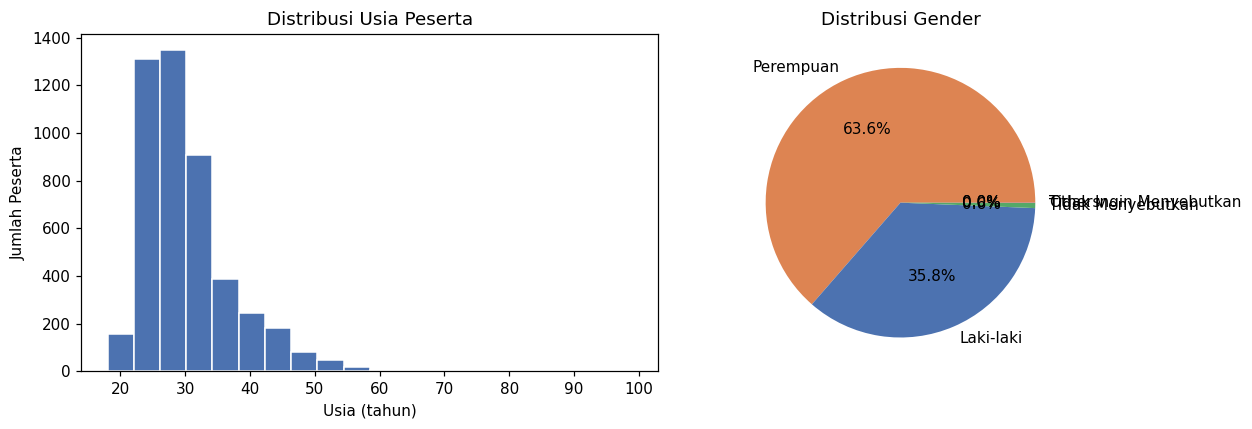

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

tidy['Usia'].dropna().plot(kind='hist', bins=20, ax=ax[0], color='#4C72B0', edgecolor='white')
ax[0].set_title('Distribusi Usia Peserta')
ax[0].set_xlabel('Usia (tahun)')
ax[0].set_ylabel('Jumlah Peserta')

gender_counts = tidy['Gender'].value_counts(dropna=True)
ax[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
          colors=['#DD8452', '#4C72B0', '#55A868', '#C44E52', '#8172B2'])
ax[1].set_title('Distribusi Gender')

plt.tight_layout()
plt.show()

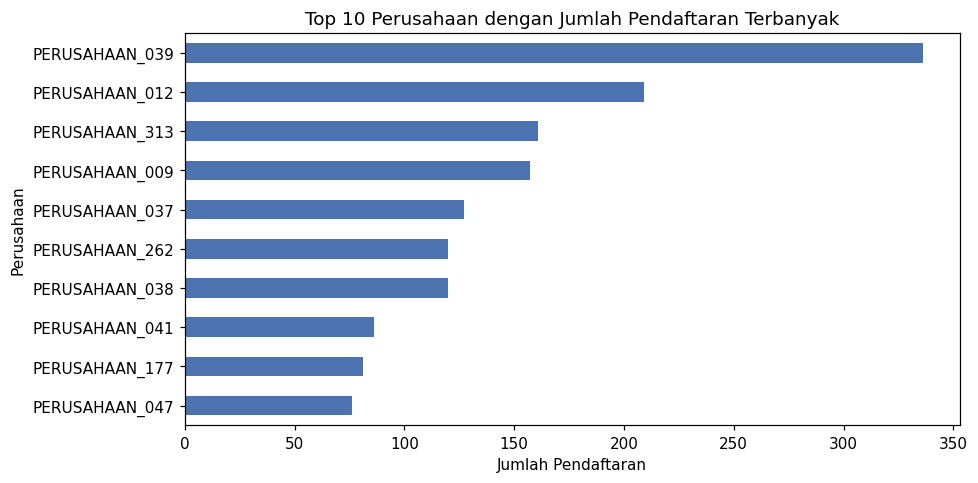

In [18]:
top_companies = tidy['Perusahaan'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(9, 4.5))
top_companies.sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Top 10 Perusahaan dengan Jumlah Pendaftaran Terbanyak')
ax.set_xlabel('Jumlah Pendaftaran')
plt.tight_layout()
plt.show()

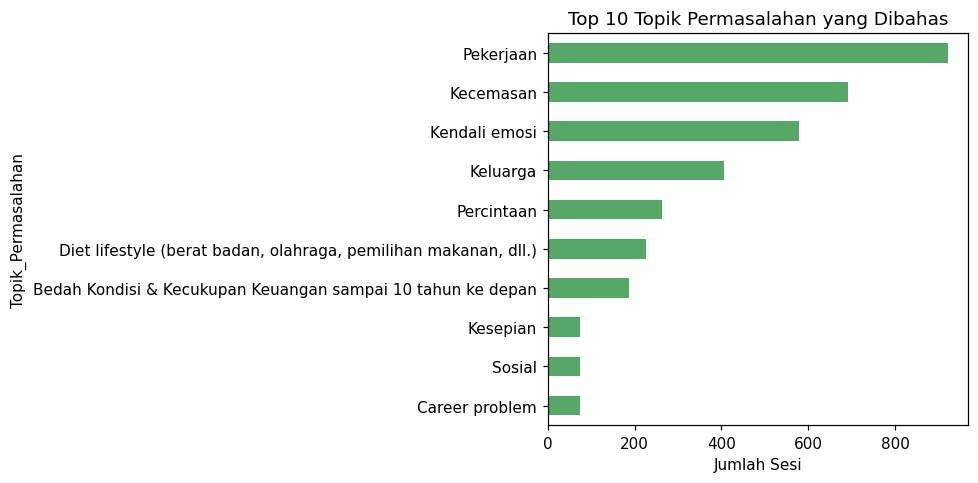

In [19]:
top_topics = tidy['Topik_Permasalahan'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(9, 4.5))
top_topics.sort_values().plot(kind='barh', ax=ax, color='#55A868')
ax.set_title('Top 10 Topik Permasalahan yang Dibahas')
ax.set_xlabel('Jumlah Sesi')
plt.tight_layout()
plt.show()

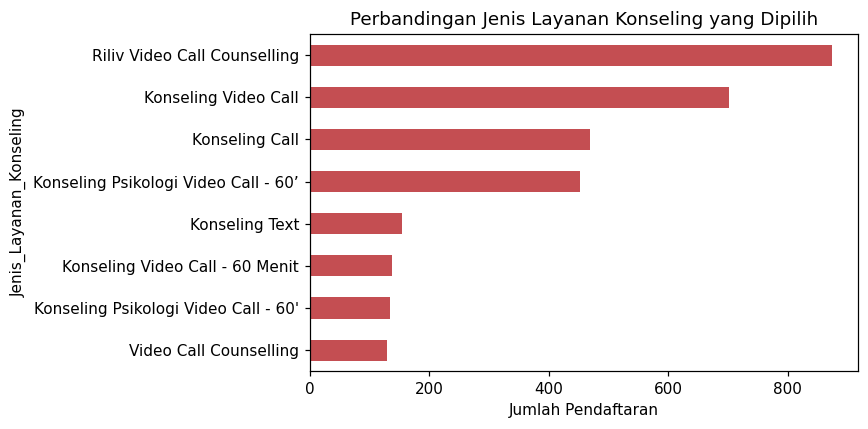

In [20]:
service_counts = tidy['Jenis_Layanan_Konseling'].value_counts().head(8)
fig, ax = plt.subplots(figsize=(8, 4))
service_counts.sort_values().plot(kind='barh', ax=ax, color='#C44E52')
ax.set_title('Perbandingan Jenis Layanan Konseling yang Dipilih')
ax.set_xlabel('Jumlah Pendaftaran')
plt.tight_layout()
plt.show()

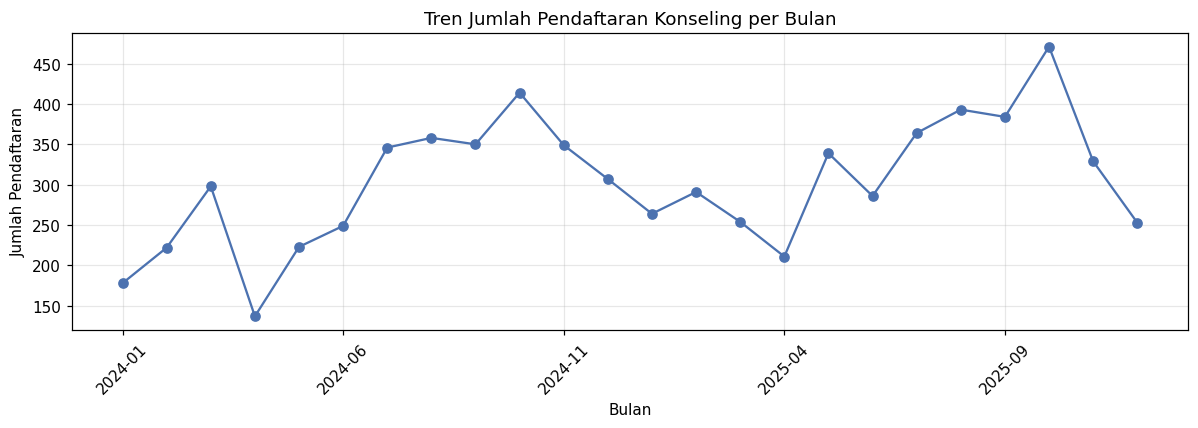

In [21]:
monthly_trend = tidy.groupby('Bulan_Sesi').size().sort_index()
fig, ax = plt.subplots(figsize=(11, 4))
monthly_trend.plot(kind='line', marker='o', ax=ax, color='#4C72B0')
ax.set_title('Tren Jumlah Pendaftaran Konseling per Bulan')
ax.set_xlabel('Bulan')
ax.set_ylabel('Jumlah Pendaftaran')
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
consent_counts = tidy['Persetujuan_Data_Consent'].value_counts()
print("Distribusi jawaban Persetujuan Data (Consent):")
print(consent_counts)
print()
status_counts = tidy['Status_Kepegawaian'].value_counts()
print("Distribusi Status Kepegawaian:")
print(status_counts)

Distribusi jawaban Persetujuan Data (Consent):
Persetujuan_Data_Consent
Saya tidak bersedia                                                                                                                                                                                                                                                1201
Saya bersedia                                                                                                                                                                                                                                                      1154
Saya bersedia mengikuti konseling dengan ketentuan di atas dan saya bersedia gambaran hasil konseling saya disampaikan kepada Tim Manajemen Perusahaan tempat saya bekerja saat ini TANPA menyebutkan data pribadi.                                                1047
Saya bersedia mengikuti konseling dengan ketentuan di atas dan saya BERSEDIA data pribadi dan hasil konseling saya disampaikan kepada Ti

## 9. Ringkasan

* Dari **7.270 baris** raw data, seluruh baris berhasil ditransformasikan menjadi tabel tidy dengan
  **1 baris = 1 pendaftaran**, dan seluruh **121 variasi label pertanyaan** berhasil dipetakan ke
  **24 kategori kolom standar** tanpa ada yang terlewat.
* Ditemukan **429 baris "sesi lanjutan"** (hanya berisi kode sesi, tanpa detail lain) yang ditandai
  lewat kolom `Is_Continuation_Session` alih-alih dihapus, supaya jejak datanya tetap bisa ditelusuri.
* Pembersihan tambahan dilakukan pada kolom Usia (ekstraksi angka + filter outlier), Gender, nama
  Perusahaan, dan Status Kepegawaian.
* Insight awal: tren bulanan pendaftaran, sebaran usia & gender, topik permasalahan terbanyak, serta
  perbandingan jenis layanan konseling — seluruhnya tersedia lebih interaktif di dashboard Streamlit
  (`dashboard_app.py`, jalankan dengan `streamlit run dashboard_app.py`).
* Seluruh proses (raw → mapping/long → tidy final) tersimpan tertelusuri di
  `data/Riliv_Data_Cleaning_Result.xlsx` dan file-file CSV terpisah di folder `data/`.
